In [1]:
import pandas as pd
import numpy as np
import optuna
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from optuna_integration import LightGBMPruningCallback

# Load Data

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

# train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv')
# test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv')

In [3]:
print(f"train shape: {train.shape} ")
print(f"test shape: {test.shape} ")

train shape: (691369, 14) 
test shape: (296302, 13) 


In [4]:
for c in train.columns:

    if train[c].dtype == "int64":
        train[c] = train[c].astype("int32")
        if c != 'addicted_label':
            test[c]  = test[c].astype("int32")

    if train[c].dtype == "float64":
        train[c] = train[c].astype("float32")
        if c != 'addicted_label':
            test[c]  = test[c].astype("float32")

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int32  
 1   age                      662440 non-null  float32
 2   daily_screen_time_hours  595515 non-null  float32
 3   social_media_hours       557374 non-null  float32
 4   gaming_hours             564548 non-null  float32
 5   work_study_hours         639851 non-null  float32
 6   sleep_hours              646889 non-null  float32
 7   notifications_per_day    623785 non-null  float32
 8   app_opens_per_day        610659 non-null  float32
 9   weekend_screen_time      579306 non-null  float32
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int32  
dtypes: float32(9), 

# Expoloratory data analysis

In [6]:
target_column = 'addicted_label'
unrelated_columns = ['id', 'gender']
categorical_columns = train.select_dtypes(include=['object', 'str']).columns.drop(['gender']).tolist()
numerical_columns = train.select_dtypes(include='number').columns.drop(['id', target_column]).tolist()


print(f"categorical columns: {categorical_columns}")
print(f"numerical columns: {numerical_columns}")
print(len(categorical_columns+numerical_columns))

categorical columns: ['stress_level', 'academic_work_impact']
numerical columns: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
11


## Taget distribution

<Axes: title={'center': 'Count (target)'}, xlabel='addicted_label'>

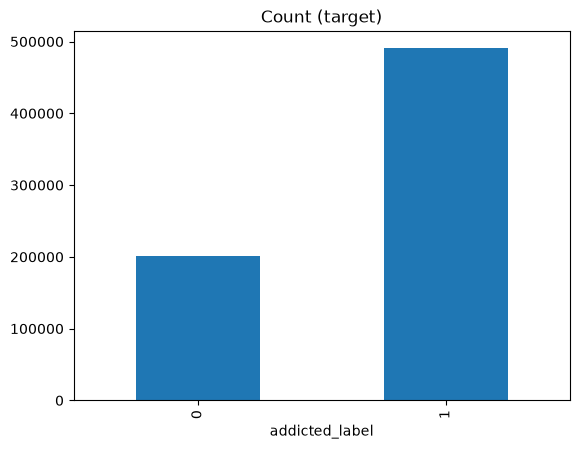

In [7]:
train.groupby(target_column).size().plot(kind='bar', title='Count (target)')

In [8]:
for col in categorical_columns:
    print(f"---------------------{col}---------------------")
    print(pd.crosstab(train[col], train[target_column], normalize='index').round(3))

---------------------stress_level---------------------
addicted_label      0      1
stress_level                
High            0.289  0.711
Low             0.289  0.711
Medium          0.294  0.706
---------------------academic_work_impact---------------------
addicted_label            0      1
academic_work_impact              
No                    0.289  0.711
Yes                   0.292  0.708


# Feature engineering

## Clean Data

In [9]:
x_train, y_train = train.drop(columns=unrelated_columns+[target_column]), train[target_column]
x_test = test.drop(columns=unrelated_columns)

print(f"x_train shape: {x_train.shape} ")
print(f"x_test shape: {x_test.shape} ")
print(f"y_train shape: {y_train.shape} ")

x_train shape: (691369, 11) 
x_test shape: (296302, 11) 
y_train shape: (691369,) 


## Missing value

In [10]:
num_imputer = SimpleImputer(strategy='median')
x_train[numerical_columns] = num_imputer.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = num_imputer.transform(x_test[numerical_columns])

cat_imputer = SimpleImputer(strategy='most_frequent')
x_train[categorical_columns] = cat_imputer.fit_transform(x_train[categorical_columns])
x_test[categorical_columns] = cat_imputer.transform(x_test[categorical_columns])

print(f"Null value count in x_train: {x_train.isna().sum().sum()}")
print(f"Null value count in x_test: {x_test.isna().sum().sum()}")

Null value count in x_train: 0
Null value count in x_test: 0


## Feature Additions

In [11]:
def add_features(frame):
    daily = frame["daily_screen_time_hours"]
    frame["recreational_screen_hours"] = (frame["social_media_hours"] + frame["gaming_hours"]).astype("float32")
    frame["weekend_minus_daily_screen"] = (frame["weekend_screen_time"] - daily).astype("float32")
    frame["screen_to_sleep_ratio"] = (daily / frame["sleep_hours"].clip(lower=0.25)).astype("float32")
    frame["notifications_per_screen_hour"] = (frame["notifications_per_day"] / daily.clip(lower=0.25)).astype("float32")
    frame["opens_per_screen_hour"] = (frame["app_opens_per_day"] / daily.clip(lower=0.25)).astype("float32")


add_features(x_train)
add_features(x_test)

print(f"x_train shape: {x_train.shape} ")
print(f"x_test shape: {x_test.shape} ")
print(f"Feture memory :{(x_train.memory_usage(deep=True).sum() + x_test.memory_usage(deep=True).sum()) / 2**20:.1f} MiB")

x_train shape: (691369, 16) 
x_test shape: (296302, 16) 
Feture memory :74.3 MiB


# Encoding categories

In [12]:
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)

for col in categorical_columns:
    le = LabelEncoder()
    all_rows = pd.concat([x_train[col], x_test[col]], axis=0).astype('string')
    le.fit(all_rows)
    x_train[col] = le.transform(x_train[col].astype('string'))
    x_test[col] = le.transform(x_test[col].astype('string'))

x_train.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,recreational_screen_hours,weekend_minus_daily_screen,screen_to_sleep_ratio,notifications_per_screen_hour,opens_per_screen_hour
0,24.0,7.77,1.83,1.59,2.11,7.46,122.0,38.0,8.63,2,0,3.42,0.860000,1.041555,15.701416,4.890605
1,19.0,5.97,1.08,1.33,3.03,8.22,76.0,19.0,9.58,2,0,2.41,3.610000,0.726277,12.730319,3.182580
2,18.0,5.09,2.31,1.33,2.20,6.25,134.0,60.0,7.47,1,1,3.64,2.380000,0.814400,26.326128,11.787819
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,1,1,2.68,2.240000,0.725424,17.445482,14.641745
4,26.0,11.20,1.87,2.81,1.95,5.25,150.0,104.0,13.39,2,0,4.68,2.190001,2.133333,13.392858,9.285714


# Hyperparameter tuning with Optuna

In [13]:
# convert x_train x_test in np.array
np_x_train, np_x_test = x_train.to_numpy(), x_test.to_numpy()

## LightGBM

In [14]:
def lgbm_objective(trial):
    params = {
        # Core Parameters for Binary Probability
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 500, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        
        # Structural Parameters (Tree Complexity)
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        
        # Regularization (To prevent overfitting)
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        
        # Subsampling (Stochastic behavior)
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        'early_stopping_rounds': 50,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_auc_scores = []

    for train_index, valid_index in skf.split(np_x_train, y_train):
        X_train_fold, X_valid_fold = x_train.iloc[train_index], x_train.iloc[valid_index]
        # X_train_fold, X_valid_fold = np_x_train[train_index], np_x_train[train_index]
        y_train_fold, y_valid_fold = y_train[train_index], y_train[valid_index]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_train_fold, y_train_fold, eval_X=X_valid_fold, eval_y=y_valid_fold)
        # model.fit(X_train_fold, y_train_fold, eval_X=X_valid_fold, eval_y=y_valid_fold, eval_metric='auc',
        #             callbacks=[LightGBMPruningCallback(trial, "auc")]
        #             )

        y_pred = model.predict_proba(X_valid_fold)[:, 1]
        auc_score = roc_auc_score(y_valid_fold, y_pred)
        fold_auc_scores.append(auc_score)
        # score = model.best_score["valid"]["auc"]
        # fold_auc_scores.append(score)

    return np.mean(fold_auc_scores)

In [15]:
lgbm_study = optuna.create_study(
    storage="sqlite:///optuna.db",
    load_if_exists=True,
    direction="maximize",
    study_name="lgbm_study"
)
lgbm_study.optimize(lgbm_objective, n_trials=50, n_jobs=1, show_progress_bar=True)

KeyboardInterrupt: 

In [ ]:
print("Best trial:", lgbm_study.best_trial)
print("Best parameters:", lgbm_study.best_params)
print("Best AUC:", lgbm_study.best_value)

Best trial: FrozenTrial(number=82, state=<TrialState.COMPLETE: 1>, values=[0.9634852076878347], datetime_start=datetime.datetime(2026, 8, 3, 8, 25, 32, 219080), datetime_complete=datetime.datetime(2026, 8, 3, 8, 28, 0, 384123), params={'n_estimators': 1708, 'learning_rate': 0.056451669639026564, 'num_leaves': 85, 'max_depth': 8, 'min_child_samples': 93, 'reg_alpha': 5.893216602219819, 'reg_lambda': 0.22367852132091334, 'subsample': 0.6561913538063671, 'colsample_bytree': 0.5001843606661323}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=2000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.2, log=True, low=0.005, step=None), 'num_leaves': IntDistribution(high=255, log=False, low=15, step=1), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'min_child_samples': IntDistribution(high=100, log=False, low=5, step=1), 'reg_alpha': FloatDistribution(high=10.0, log=True, low=1e-08, step=None), 

In [ ]:
optuna.visualization.plot_optimization_history(lgbm_study).show()

In [ ]:
optuna.visualization.plot_param_importances(lgbm_study).show()

### Predict test set

Best parameters: {'num_leaves': 2307, 'max_depth': 5, 'learning_rate': 0.029867202165887848, 'feature_fraction': 0.4787902697542432, 'bagging_fraction': 0.853212068299793, 'n_estimators': 6953, 'min_child_samples': 15, 'reg_alpha': 8.419400347025483}

{'num_leaves': 1076,
 'max_depth': 7,
 'learning_rate': 0.028059820996199865,
 'feature_fraction': 0.9628865847053244,
 'bagging_fraction': 0.5612949150375323,
 'n_estimators': 5308,
 'min_child_samples': 58,
 'reg_alpha': 1.8606686805022264e-07,
 'reg_lambda': 0.00018042860651219623}

{'num_leaves': 197, 'max_depth': 7, 'learning_rate': 0.12374582403244139, 'n_estimators': 1018, 'min_child_samples': 165, 'feature_fraction': 0.8032504745047699, 'bagging_fraction': 0.5112371836091172, 'reg_alpha': 7.9518075302837135, 'reg_lambda': 0.5466660773750741}

In [ ]:
lgbm_best_params = lgbm_study.best_params.copy()
lgbm_best_params.update({"random_state": 42, "verbose": -1, "n_jobs": -1})
lgbm_final_model = lgb.LGBMClassifier(**lgbm_best_params)
lgbm_final_model.fit(x_train, y_train)

probabilities = lgbm_final_model.predict_proba(x_test)[:, 1]

submission = pd.DataFrame({'id': test['id'], 'addicted_label': probabilities})
submission.to_csv('submission/lgbm_submission.csv', index=False)

joblib.dump(lgbm_final_model, 'models/lgbm_final_model.pkl')


['models/lgbm_final_model.pkl']

## Catboost

In [ ]:
def catboost_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations',100, 2000, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 100),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.1, 20.0),
        'random_strength': trial.suggest_float('random_strength', 1.0, 2.0),
        'depth': trial.suggest_int('depth', 3, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 300),
        'use_best_model': True,
        'random_seed': 42
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_auc_scores = []

    for train_index, valid_index in skf.split(x_train, y_train):
        X_train_fold, X_valid_fold = x_train.iloc[train_index], x_train.iloc[valid_index]
        y_train_fold, y_valid_fold = y_train[train_index], y_train[valid_index]

        model = cb.CatBoostClassifier(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=(X_valid_fold, y_valid_fold), early_stopping_rounds=50, verbose=False)

        y_pred = model.predict_proba(X_valid_fold)[:, 1]
        auc_score = roc_auc_score(y_valid_fold, y_pred)
        fold_auc_scores.append(auc_score)

    return np.mean(fold_auc_scores)

In [ ]:
# cb_study = optuna.create_study(direction='maximize')
cb_study = optuna.create_study(
    storage="sqlite:///optuna.db",
    load_if_exists=True,
    direction="maximize",
    study_name="cb_study"
)
cb_study.optimize(catboost_objective, n_trials=50, n_jobs=1, show_progress_bar=True)

[I 2026-08-03 08:59:39,836] Using an existing study with name 'cb_study' instead of creating a new one.


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-03 09:03:35,125] Trial 51 finished with value: 0.9623961527689057 and parameters: {'iterations': 2440, 'learning_rate': 0.07845915370674703, 'l2_leaf_reg': 20.690276061586466, 'bagging_temperature': 19.272485089158693, 'random_strength': 1.3707066239931733, 'depth': 6, 'min_data_in_leaf': 18}. Best is trial 51 with value: 0.9623961527689057.
[I 2026-08-03 09:07:17,188] Trial 52 finished with value: 0.9623366790425054 and parameters: {'iterations': 2372, 'learning_rate': 0.08009008946787151, 'l2_leaf_reg': 20.431204245118106, 'bagging_temperature': 19.461917910032412, 'random_strength': 1.3743315011631851, 'depth': 6, 'min_data_in_leaf': 19}. Best is trial 51 with value: 0.9623961527689057.
[I 2026-08-03 09:10:42,560] Trial 53 finished with value: 0.9617997157337417 and parameters: {'iterations': 2426, 'learning_rate': 0.07867462512696742, 'l2_leaf_reg': 20.455959504013848, 'bagging_temperature': 19.96168400904943, 'random_strength': 1.366262000756469, 'depth': 5, 'min_data_i

In [ ]:
optuna.visualization.plot_optimization_history(cb_study).show()

In [ ]:
optuna.visualization.plot_param_importances(cb_study).show()

In [ ]:
print(f"Best trial: {cb_study.best_trial}")
print(f"Best parameters: {cb_study.best_params}")

cb_best_params = cb_study.best_params.copy()
cb_best_params.update({"random_seed": 42, "logging_level": 'Silent'})

Best trial: FrozenTrial(number=95, state=<TrialState.COMPLETE: 1>, values=[0.9626321446895972], datetime_start=datetime.datetime(2026, 8, 3, 11, 20, 55, 241503), datetime_complete=datetime.datetime(2026, 8, 3, 11, 24, 14, 991338), params={'iterations': 2373, 'learning_rate': 0.09506074279752405, 'l2_leaf_reg': 26.21159537491894, 'bagging_temperature': 19.523992991116334, 'random_strength': 1.1510426429452567, 'depth': 6, 'min_data_in_leaf': 268}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'iterations': IntDistribution(high=2500, log=True, low=500, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.005, step=None), 'l2_leaf_reg': FloatDistribution(high=100.0, log=False, low=1.0, step=None), 'bagging_temperature': FloatDistribution(high=20.0, log=False, low=0.1, step=None), 'random_strength': FloatDistribution(high=2.0, log=False, low=1.0, step=None), 'depth': IntDistribution(high=10, log=False, low=1, step=1), 'min_data_in_leaf': IntDistrib

### Predict test set

In [ ]:
cb_final_model = cb.CatBoostClassifier(**cb_best_params)
cb_final_model.fit(x_train, y_train)

cb_probabilities = cb_final_model.predict_proba(x_test)[:, 1]
cb_submission = pd.DataFrame({'id': test['id'], 'addicted_label': cb_probabilities})
cb_submission.to_csv('submission/catboost_submission.csv', index=False)

joblib.dump(cb_final_model, 'models/catboost_final_model.pkl')

['models/catboost_final_model.pkl']

## XGBoost 

In [ ]:
def xgb_objective(trial):
    params = {
        # Task & Probability Configuration (Fixed)
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        # "eval_metric": trial.suggest_categorical("eval_metric", ["logloss", "auc"]),
        'early_stopping_rounds': 50,

        # 1. Structural & Core Hyperparameters
        "n_estimators": trial.suggest_int("n_estimators", 100, 1500), # step 50
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        
        # 2. Overfitting & Leaf Controls (Highly recommended for probabilities)
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        
        # 3. Sampling / Stochasticity (Adds robustness against noise)
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        
        # 4. Regularization (Prevents extreme overconfident probabilities)
        "alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        
        'random_state': 42,
        'n_jobs': -1,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_auc_scores = []

    for train_index, valid_index in skf.split(x_train, y_train):
        X_train_fold, X_valid_fold = x_train.iloc[train_index], x_train.iloc[valid_index]
        y_train_fold, y_valid_fold = y_train[train_index], y_train[valid_index]

        model = xgb.XGBClassifier(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_valid_fold, y_valid_fold)], verbose=False)

        y_pred = model.predict_proba(X_valid_fold)[:, 1]
        auc_score = roc_auc_score(y_valid_fold, y_pred)
        fold_auc_scores.append(auc_score)

    return np.mean(fold_auc_scores)

In [ ]:
# xgb_study = optuna.create_study(direction='maximize')
xgb_study = optuna.create_study(
    storage="sqlite:///optuna.db",
    load_if_exists=True,
    direction="maximize",
    study_name="xgb_study"
)
xgb_study.optimize(xgb_objective, n_trials=50, n_jobs=1, show_progress_bar=True)

[I 2026-08-03 11:45:46,132] Using an existing study with name 'xgb_study' instead of creating a new one.


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-03 11:56:25,830] Trial 50 finished with value: 0.9609755153112026 and parameters: {'tree_method': 'approx', 'n_estimators': 2000, 'learning_rate': 0.0649016583429313, 'max_depth': 3, 'min_child_weight': 10, 'gamma': 6.066490658996983e-07, 'subsample': 0.8386853566787285, 'colsample_bytree': 0.5904575832608497, 'alpha': 0.0001313260668585875, 'lambda': 7.167022589272533e-08}. Best is trial 33 with value: 0.9633423253359101.
[I 2026-08-03 11:58:34,122] Trial 51 finished with value: 0.9634860076963934 and parameters: {'tree_method': 'hist', 'n_estimators': 1500, 'learning_rate': 0.08146864198653461, 'max_depth': 6, 'min_child_weight': 6, 'gamma': 1.8588665680064889e-06, 'subsample': 0.9284885171657572, 'colsample_bytree': 0.5343053731343128, 'alpha': 1.399378662352395e-07, 'lambda': 0.014793822196741507}. Best is trial 51 with value: 0.9634860076963934.
[I 2026-08-03 12:00:54,795] Trial 52 finished with value: 0.9632287790817369 and parameters: {'tree_method': 'hist', 'n_estima

KeyboardInterrupt: 

In [ ]:
optuna.visualization.plot_optimization_history(xgb_study).show()

In [ ]:
optuna.visualization.plot_param_importances(xgb_study).show()

In [ ]:
print(f"Best trial: {xgb_study.best_trial.value}")
print(f"Best parameters: {xgb_study.best_params}")

xgb_best_params = xgb_study.best_params.copy()
xgb_best_params.update({"random_state": 42, "n_jobs": -1})

Best trial: 0.9633423253359101
Best parameters: {'n_estimators': 1887, 'learning_rate': 0.09616250629872691, 'max_depth': 6, 'min_child_weight': 7, 'gamma': 3.213383468931614e-07, 'subsample': 0.8974974251017336, 'colsample_bytree': 0.7820479091157038, 'alpha': 6.573038974094408e-05, 'lambda': 0.000857817693949785}


### Predict test set

In [ ]:
xgb_final_model = xgb.XGBClassifier(**xgb_best_params)
xgb_final_model.fit(x_train, y_train)

xgb_probabilities = xgb_final_model.predict_proba(x_test)[:, 1]
xgb_submission = pd.DataFrame({'id': test['id'], 'addicted_label': xgb_probabilities})
xgb_submission.to_csv('submission/xgboost_submission.csv', index=False)

joblib.dump(xgb_final_model, 'models/xgboost_final_model.pkl')


['models/xgboost_final_model.pkl']